## 1. Wczytanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

In [2]:
df = pd.read_csv('..//data/train.csv')
print(f"Wymiary zbioru: {df.shape}")
df.head()

Wymiary zbioru: (593994, 13)


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


## 2. Ocena jakosci danych

In [3]:
print("Typy danych:")
print(df.dtypes)
print(f"\nBrakujace wartosci:")
print(df.isnull().sum())
print(f"\nLaczna liczba brakow: {df.isnull().sum().sum()}")
print(f"\nZduplikowane wiersze: {df.duplicated().sum()}")

Typy danych:
id                        int64
annual_income           float64
debt_to_income_ratio    float64
credit_score              int64
loan_amount             float64
interest_rate           float64
gender                   object
marital_status           object
education_level          object
employment_status        object
loan_purpose             object
grade_subgrade           object
loan_paid_back          float64
dtype: object

Brakujace wartosci:
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

Laczna liczba brakow: 0

Zduplikowane wiersze: 0


Zbior jest czysty - brak nulli i duplikatow. Mamy 5 cech numerycznych, 5 kategorycznych, kolumne id oraz zmienna docelowa.

In [4]:
df.describe().round(2)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.00,593994.00,593994.00,593994.00,593994.00,593994.00,593994.0
mean,296996.50,48212.20,0.12,680.92,15020.30,12.36,0.8
std,171471.44,26711.94,0.07,55.42,6926.53,2.01,0.4
min,0.00,6002.43,0.01,395.00,500.09,3.20,0.0
25%,148498.25,27934.40,0.07,646.00,10279.62,10.99,1.0
50%,296996.50,46557.68,0.10,682.00,15000.22,12.37,1.0
75%,445494.75,60981.32,0.16,719.00,18858.58,13.68,1.0
max,593993.00,393381.74,0.63,849.00,48959.95,20.99,1.0


## 3. Zmienna docelowa

Rozklad zmiennej docelowej:
loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

Stosunek splaconych do niesplaconych: 3.97:1


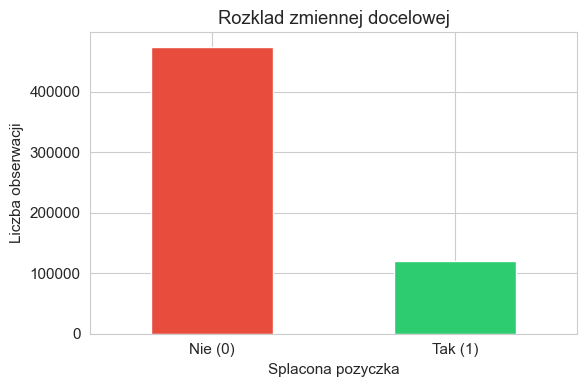

In [5]:
target_dist = df['loan_paid_back'].value_counts(normalize=True)
print("Rozklad zmiennej docelowej:")
print(target_dist)
print(f"\nStosunek splaconych do niesplaconych: {target_dist[1]/target_dist[0]:.2f}:1")

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df['loan_paid_back'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], ax=ax)
ax.set_title('Rozklad zmiennej docelowej')
ax.set_xlabel('Splacona pozyczka')
ax.set_ylabel('Liczba obserwacji')
ax.set_xticklabels(['Nie (0)', 'Tak (1)'], rotation=0)
plt.tight_layout()
plt.show()

Okolo 80% pozyczek jest splaconych - dane sa umiarkowanie niezbalansowane. Naiwny klasyfikator osiagnalby ~80% accuracy, dlatego AUC jest wlasciwsza metryka.

## 4. Analiza jednowymiarowa - cechy numeryczne

In [ ]:
num_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
desc = df[num_cols].describe()
# DODAJEMY MEDIANĘ I MODĘ, ponieważ są bardziej odporne na wartości odstające niż średnia
desc.loc['median'] = df[num_cols].median()
desc.loc['mode'] = df[num_cols].mode().iloc[0]
desc = desc.drop('count')

desc

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345
std,26711.942078,0.068573,55.424956,6926.530568,2.008959
min,6002.430000,0.011000,395.000000,500.090000,3.200000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000
median,46557.680000,0.096000,682.000000,15000.220000,12.370000
mode,51351.710000,0.090000,678.000000,12892.250000,12.310000


annual_income Rozkład jest prawoskośny (średnia > mediana), ale moda przyjmuje wartość wyższą niż średnia. 
Może to wskazywać na koncentrację obserwacji w określonym przedziale dochodów przy jednoczesnym występowaniu wysokich wartości odstających.
Obecność wysokich wartości maksymalnych wskazuje na występowanie obserwacji odstających. 
Duże odchylenie standardowe sugeruje znaczną zmienność dochodów w badanej populacji.
# 
debt_to_income_ratio Typowy rozkład prawoskośny (moda < mediana < średnia). Większość obserwacji koncentruje się w dolnym zakresie wartości 
(około 0.07–0.16), natomiast obecność wysokich wartości maksymalnych (0.627) wskazuje na występowanie obserwacji odstających. 
# 
credit_score Rozkład zbliżony do symetrycznego, z bardzo lekką lewoskośnością (średnia < mediana). Dane są skoncentrowane wokół wartości centralnej,
a odchylenie standardowe umiarkowane. Większość obserwacji mieści się w stosunkowo wąskim przedziale, co wskazuje na stabilność credit_score.
# 
loan_amount Rozkład jest zbliżony do symetrycznego, co potwierdza bardzo podobna wartość średniej i mediany. 
Jednocześnie niższa wartość mody oraz obecność wartości maksymalnych sugerują lekką prawoskośność rozkładu. Dane wykazują umiarkowaną zmienność.
# 
interest_rate Rozkład bliski normalnemu - średnia, moda, mediana zbliżone do siebie. Zmienna charakteryzuje się umiarkowaną zmiennością,
a większość obserwacji mieści się w stosunkowo wąskim przedziale. Dane są stabilne i nie wykazują istotnej asymetrii, choć mogą występować
pojedyncze wartości odstające.

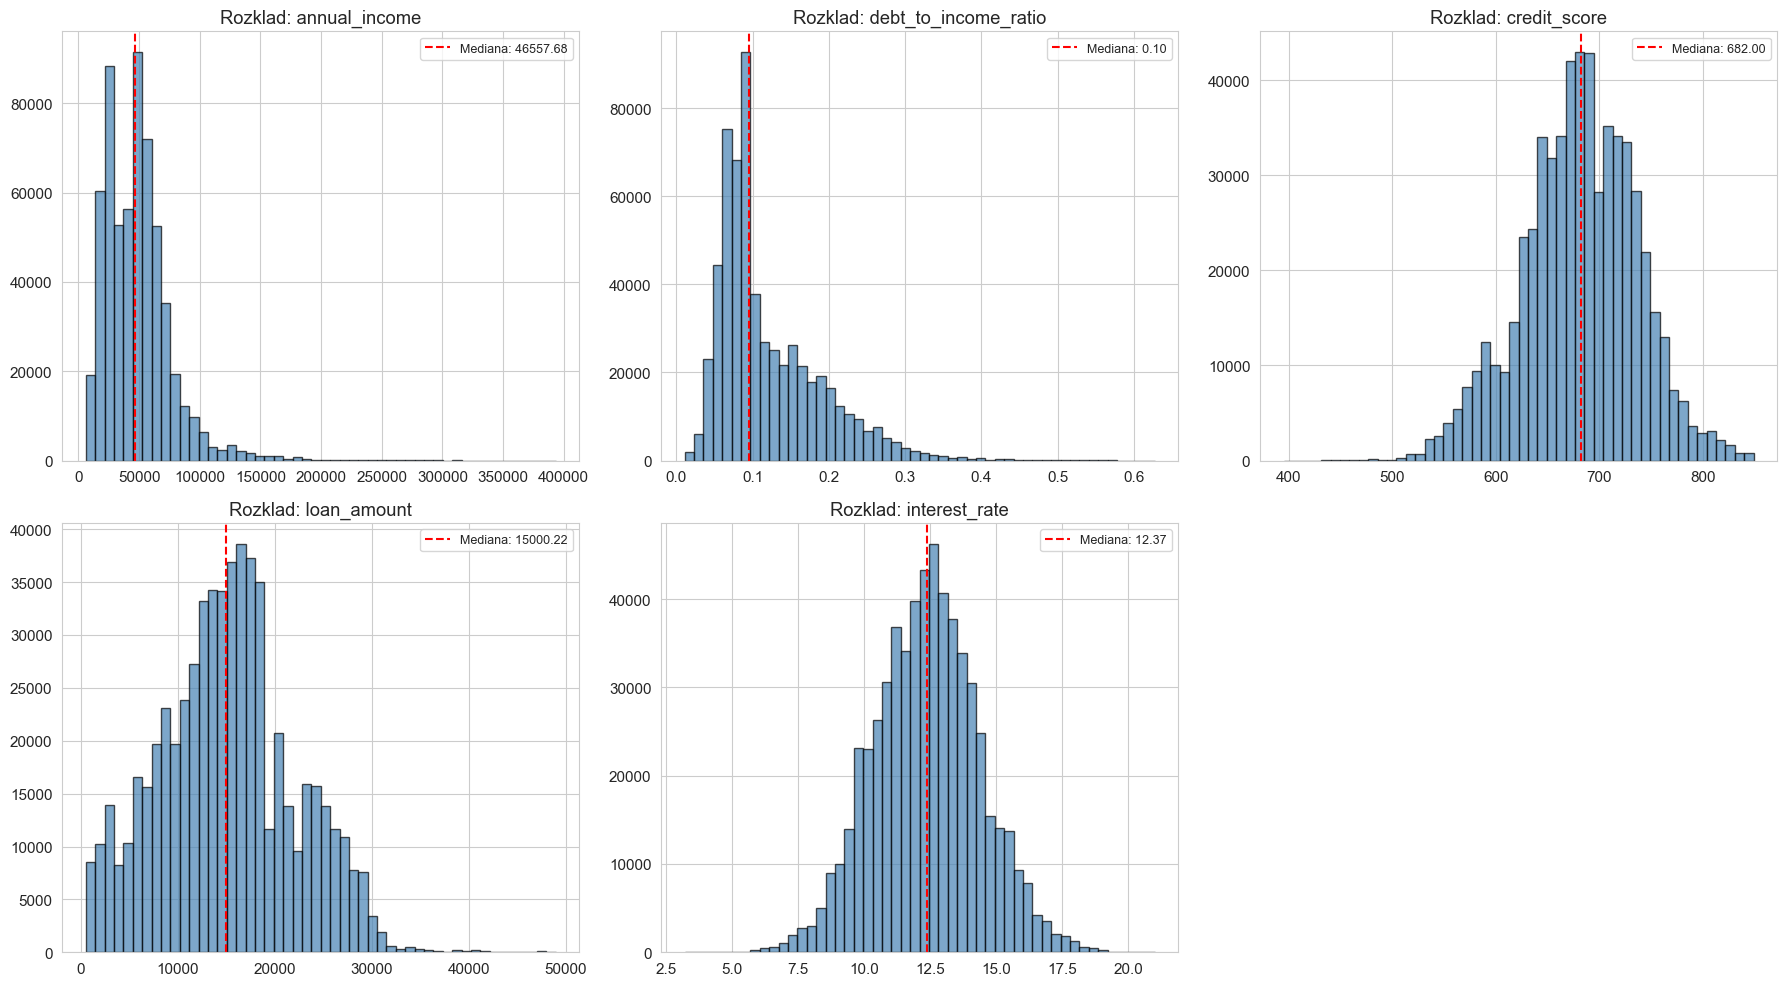

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    df[col].hist(bins=50, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(df[col].median(), color='red', linestyle='--', label=f'Mediana: {df[col].median():.2f}')
    ax.set_title(f'Rozklad: {col}')
    ax.legend(fontsize=9)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

- annual_income - silna prawoskosnosc, outliery z bardzo wysokimi dochodami. Mediana znacznie nizsza od sredniej.
- debt_to_income_ratio - prawoskosny, wiekszosc pozyczkobiorcow ma niski DTI, ale jest dlugi ogon.
- credit_score - rozklad zblizony do normalnego, stabilna cecha.
- loan_amount - prawoskosny z outlierami duzych kredytow.
- interest_rate - w miare symetryczny, stosunkowo stabilny.

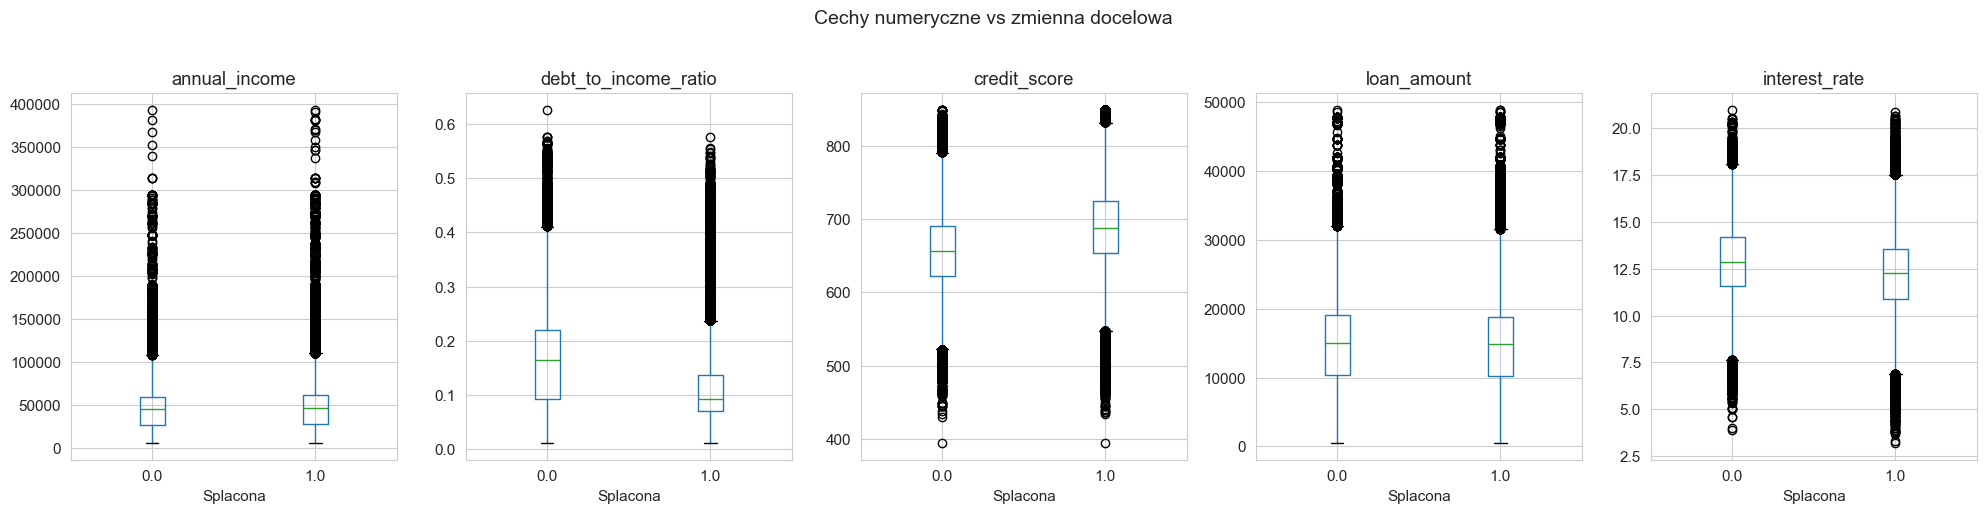

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='loan_paid_back', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('Splacona')
plt.suptitle('Cechy numeryczne vs zmienna docelowa', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

- credit_score - wyrazna separacja, splacajacy maja wyzsze wyniki
- debt_to_income_ratio - silny separator, defaultujacy maja znacznie wyzszy DTI
- interest_rate - umiarkowana separacja, wyzsze stopy procentowe koreluja z wiekszym ryzykiem
- annual_income i loan_amount - slaba separacja, rozklady sie w duzej mierze pokrywaja

## 5. Analiza jednowymiarowa - cechy kategoryczne

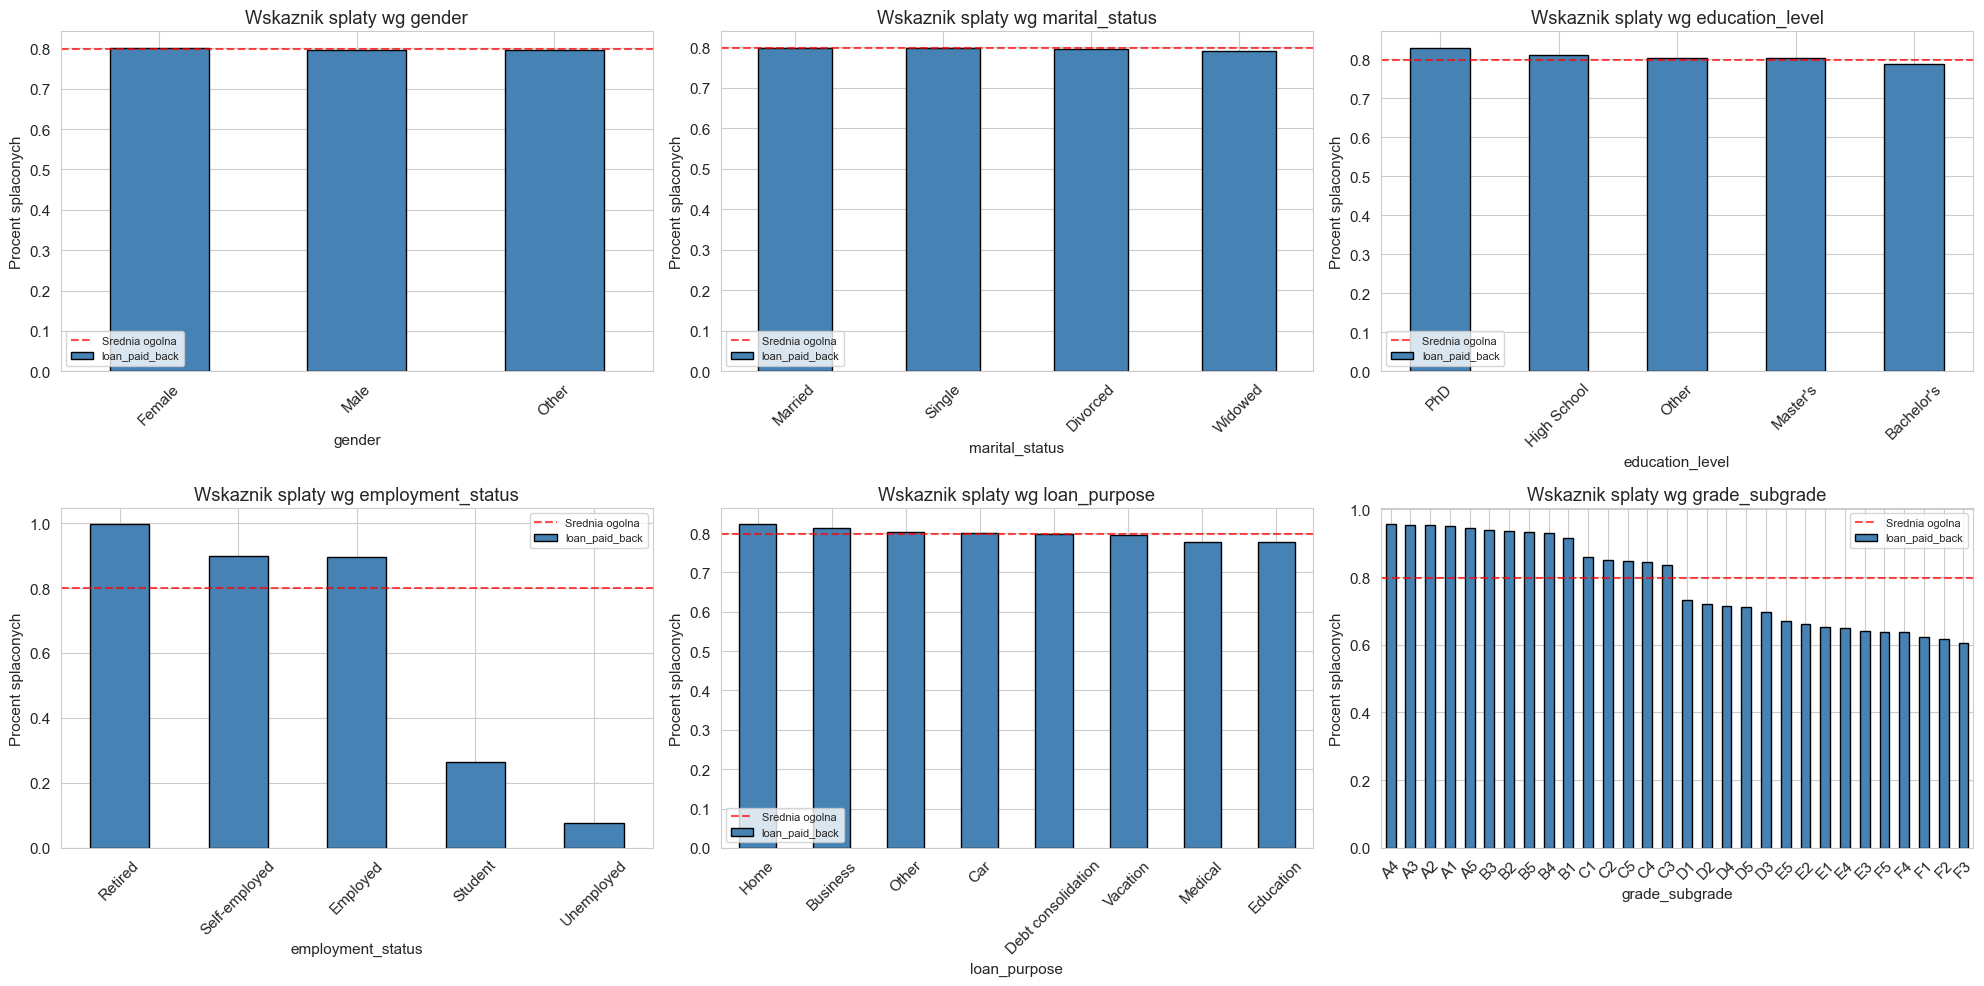

In [8]:
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    repay_rate = df.groupby(col)['loan_paid_back'].mean().sort_values(ascending=False)
    repay_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Wskaznik splaty wg {col}')
    axes[i].set_ylabel('Procent splaconych')
    axes[i].axhline(y=df['loan_paid_back'].mean(), color='red', linestyle='--', alpha=0.7, label='Srednia ogolna')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- grade_subgrade - bardzo silna, praktycznie liniowa zaleznosc. Klasy A maja najwyzsza splacalnosc, F najnizsza. Najsilniejsza cecha kategoryczna.
- employment_status - studenci i bezrobotni maja nizsza splacalnosc.
- education_level, gender, marital_status - slaby lub znikomy wplyw.
- loan_purpose - niewielkie roznice miedzy kategoriami.

## 6. Analiza korelacji

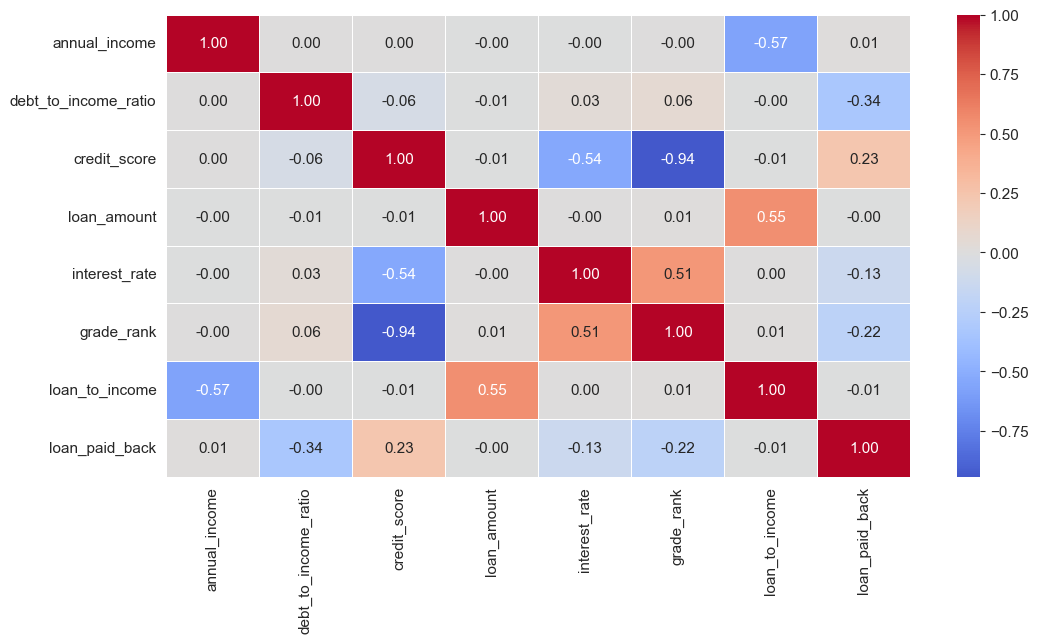

In [15]:
df_corr = df.copy()
df_corr['loan_to_income'] = df_corr['loan_amount'] / df_corr['annual_income']
grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5}
df_corr['grade_rank'] = df_corr['grade_subgrade'].str[0].map(grade_map)

corr_cols = ['annual_income', 'debt_to_income_ratio', 'credit_score', 
             'loan_amount', 'interest_rate', 'grade_rank', 'loan_to_income', 'loan_paid_back']

corr = df_corr[corr_cols].corr()


sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
plt.show()

-annual_income - loan_to_income oraz  loan_amount - loan_to_income umiarkowanie silne korelacje 
co jest naturalne, ponieważ loan_to_income było obliczone na postawie pozostałych 2 zmmiennych
#
-credit_score - interest_rate - umiarkowanie silna ujemna korelacja, prawdopodobnie wyższy scoring -> niższe oprocentowanie
#
-debt_to_income_ratio - loan_paid_back - umiarkowana ujemna korelacja, osoby z wyższym DTI częściej nie spłacają pożyczki w całości
#
-credit_score - loan_paid_back -  umiarkowana dodatnia korelacja, wyższy scoring kredytowy jest umiarkowanie związany z faktem spłacenia pożyczki
#
-debt_to_income_ratio nie jest liniowo skorelowane ani z loan_ammount ani z annual_income, trudno określić na jakiej podstawie jest obliczne
#
-loan_paid_back ma znaczącą korelację jedynie z debt_to_income_ratio, credit_score i interest_rate; są to najważniejsze predykatory spłacalności

## 7. Eksperymenty z feature engineeringiem

Przetestowalismy dwa podejscia:
1. Minimalne kodowanie - tylko kodowanie ordinalne grade_subgrade i education_level, natywna obsluga kategorii przez modele (12 cech)
2. Rozszerzony feature engineering - dodatkowe cechy pochodne (loan_to_income, disposable_income, risk_score_ratio, dti_squared, loan_per_credit_point) + one-hot encoding (~30 cech)

In [ ]:
def prepare_base_data(df):
    df = df.copy()
    education_ranking = {"PhD": 5, "Master's": 4, "Bachelor's": 3, "High School": 2, "Other": 1}
    df['education_rank'] = df['education_level'].map(education_ranking)
    df['subgrade_num'] = df['grade_subgrade'].str[1:].astype(float)
    grade_map = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
    df['grade_rank'] = df['grade_subgrade'].str[0].map(grade_map)
    cat_columns = ['gender', 'marital_status', 'employment_status', 'loan_purpose']
    for col in cat_columns:
        df[col] = df[col].astype('category')
    cols_to_drop = ['id', 'education_level', 'grade_subgrade']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    return df

def prepare_extended_data(df):
    df = df.copy()
    df['grade_letter'] = df['grade_subgrade'].str[0]
    df['subgrade_num'] = df['grade_subgrade'].str[1:].astype(int)
    grade_map = {'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6}
    df['grade_letter_rank'] = df['grade_letter'].map(grade_map)
    del df['grade_subgrade'], df['grade_letter']
    education_ranking = {"PhD": 5, "Master's": 4, "Bachelor's": 3, "High School": 2, "Other": 1}
    df['education_rank'] = df['education_level'].map(education_ranking)
    del df['education_level']
    df = pd.get_dummies(df, columns=['gender', 'marital_status', 'employment_status', 'loan_purpose'], drop_first=True)
    df['loan_to_income'] = df['loan_amount'] / df['annual_income']
    df['disposable_income'] = df['annual_income'] * (1 - df['debt_to_income_ratio'])
    df['risk_score_ratio'] = df['interest_rate'] / (df['credit_score'] + 1)
    df['dti_squared'] = df['debt_to_income_ratio'] ** 2
    df['loan_per_credit_point'] = df['loan_amount'] / df['credit_score']
    cols_to_drop = ['id']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    return df

print(f"Podejscie 1 (minimalne):   {prepare_base_data(df).shape[1] - 1} cech")
print(f"Podejscie 2 (rozszerzone): {prepare_extended_data(df).shape[1] - 1} cech")

Podejscie 1 (minimalne):   12 cech
Podejscie 2 (rozszerzone): 29 cech


### Porownanie: minimalne vs rozszerzone cechy

Przeprowadzilismy porownanie na 5-fold CV z LightGBM (parametry domyslne):

| Podejscie | Liczba cech | OOF AUC |
|-----------|------------|---------|
| Minimalne kodowanie (natywne kategorie) | 12 | **0.9209** |
| Rozszerzony FE + one-hot | ~30 | 0.9192 |

Wnioski: podejscie minimalne daje nieznacznie lepsze wyniki. Modele gradient boosting same odkrywaja interakcje miedzy cechami poprzez podzialy w drzewach - reczne dodawanie cech typu loan_to_income czy dti_squared nie przynosi korzysci, a moze nawet dodawac szum. Natywna obsluga kategorii tez dziala lepiej niz one-hot encoding w kontekscie modeli drzewiastych.

### Decyzja: uzywamy podejscia minimalnego

## 8. Waznosc cech

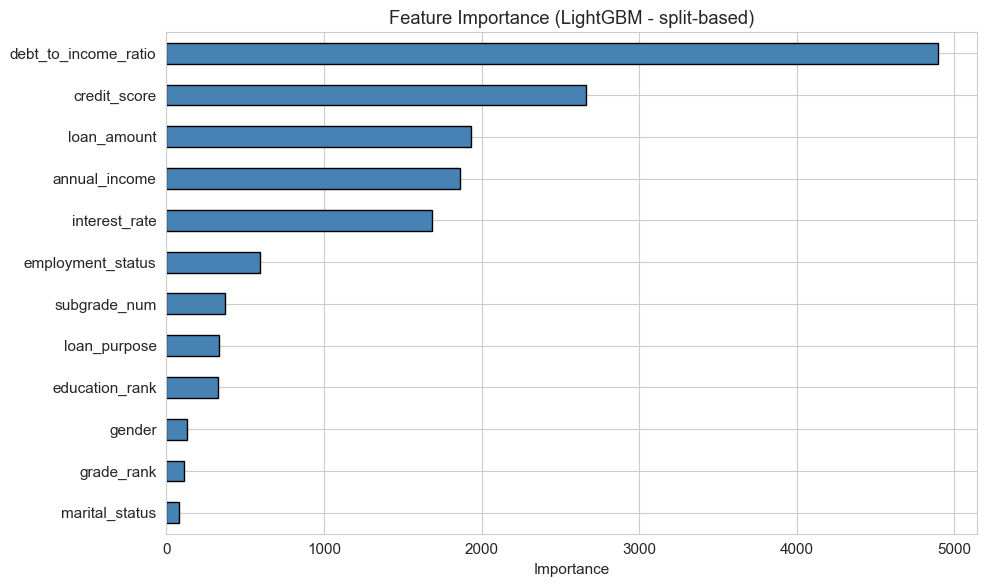

In [11]:
import lightgbm as lgb

df_base = prepare_base_data(df)
X = df_base.drop(columns=['loan_paid_back'])
y = df_base['loan_paid_back']

model_fi = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=42, verbosity=-1)
model_fi.fit(X, y)

importances = pd.Series(model_fi.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance (LightGBM - split-based)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Ranking waznosci cech:
1. debt_to_income_ratio - zdecydowanie dominujaca cecha, model najczesciej splituje wlasnie po niej
2. credit_score - druga najwazniejsza, zgodne z analiza korelacji
3. loan_amount i annual_income - na podobnym poziomie, umiarkowana waznosc
4. interest_rate - koduje ocene ryzyka ze strony pozyczkodawcy
5. employment_status - najsilniejsza z kategorycznych
6. subgrade_num, loan_purpose, education_rank - nizsza waznosc, ale wciaz wnosza cos do modelu
7. gender, grade_rank, marital_status - marginalna waznosc, ale nie przeszkadzaja

### Modelowanie

Najlepsze parametry do modeli zostały znalezione w optunie, analizę i egzekucję mozna znaleźć w pliku hiperparams_finding.ipynb